# 🌧️ Clasificación de Precipitación con TNN - Dataset JUN
**Tarea:** Clasificación multiclase (3 clases)  
**Horizonte:** 1 hora  
**Arquitectura:** Temporal Neural Network (Conv1D)  
**Clases:**
- `0` — Sin lluvia: 0 mm/h
- `1` — Lluvia leve: 0.1 – 5 mm/h
- `2` — Lluvia fuerte: > 5 mm/h

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, Dense, Dropout, Flatten,
    MaxPooling1D, BatchNormalization, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

print(f'TensorFlow version: {tf.__version__}')
print(f'Pandas version: {pd.__version__}')

TensorFlow version: 2.21.0
Pandas version: 2.3.3


## 2. Carga del Dataset

In [ ]:
# ============================================================
# AJUSTA ESTA RUTA AL ARCHIVO CSV DE TU DATASET JUN
# ============================================================
FILE_PATH = '../../Datasets/JUN_consolid_f15.csv'  

df = pd.read_csv(
    FILE_PATH,
    parse_dates=['TIMESTAMP'],
    index_col='TIMESTAMP',
    na_values=['NA', 'NaN', '']
)

print(f'Shape original: {df.shape}')
print(f'Rango de fechas: {df.index.min()} → {df.index.max()}')
df.head(8)

Shape original: (375325, 53)
Rango de fechas: 2015-06-22 15:00:00 → 2026-03-06 06:00:00


,BattV_Avg,PTemp_C_Avg,LWmV_Avg,Rain_mm_Tot,AirTC_Avg,RH_Max,SlrkW_Avg,SlrMJ_Tot,NR_Wm2_Avg,VW,...,VW_3_Min,PA_uS_3_Max,PA_uS_3_Min,NR_Wm2_Max,NR_Wm2_Min,CNR_Wm2_Max,CNR_Wm2_Min,CNR_Wm2_Avg,RECORD,WindDir_Avg
TIMESTAMP,,,,,,,,,,,,,,,,,,,,,
2015-06-22 15:00:00,13.340000,21.530000,280.200000,0.0,20.970000,99.9,0.217000,0.048850,191.300000,0.549000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 15:15:00,13.293333,21.606667,291.000000,0.0,21.050000,100.0,0.112000,0.092645,94.896667,0.549000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 15:30:00,13.250000,21.530000,330.933333,0.0,20.900000,100.0,0.085000,0.076796,63.973333,0.547333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 15:45:00,13.196667,21.376667,349.033333,0.0,20.836667,100.0,0.070000,0.063112,51.396667,0.547000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 16:00:00,13.116667,21.253333,338.266667,0.0,20.876667,100.0,0.040333,0.036253,28.443333,0.547000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 16:15:00,13.150000,21.156667,354.033333,0.0,20.766667,100.0,0.057333,0.051879,44.036667,0.546333,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 16:30:00,13.063333,21.066667,369.900000,0.0,20.733333,100.0,0.023000,0.020808,14.613333,0.546000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-06-22 16:45:00,12.983333,21.020000,398.433333,0.0,20.856667,100.0,0.017000,0.015363,10.841000,0.546000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Resampleo de 15 min → 1 Hora

In [4]:
RAIN_COL  = 'Rain_mm_Tot'
other_cols = [c for c in df.columns if c != RAIN_COL]

df_mean   = df[other_cols].resample('1H').mean()
df_rain   = df[[RAIN_COL]].resample('1H').sum()
df_hourly = pd.concat([df_mean, df_rain], axis=1)

# Verificación
total_15min = df[RAIN_COL].sum()
total_1h    = df_hourly[RAIN_COL].sum()
print(f'Shape 15 min : {df.shape}')
print(f'Shape 1 hora : {df_hourly.shape}')
print(f'Total lluvia (15 min): {total_15min:.4f} mm')
print(f'Total lluvia (1 hora): {total_1h:.4f} mm  ✅')

Shape 15 min : (375325, 53)
Shape 1 hora : (93832, 53)
Total lluvia (15 min): 16737.3980 mm
Total lluvia (1 hora): 16737.3980 mm  ✅


## 4. Creación de la Variable Objetivo (3 Clases)

| Clase | Etiqueta | Umbral |
|-------|----------|--------|
| 0 | Sin lluvia | 0 mm/h |
| 1 | Lluvia leve | 0.1 – 5 mm/h |
| 2 | Lluvia fuerte | > 5 mm/h |

=== Distribución de clases ===
  Clase 0 (Sin lluvia): 74241 muestras (79.1%)
  Clase 1 (Lluvia leve): 15490 muestras (16.5%)
  Clase 2 (Lluvia fuerte):  4101 muestras (4.4%)


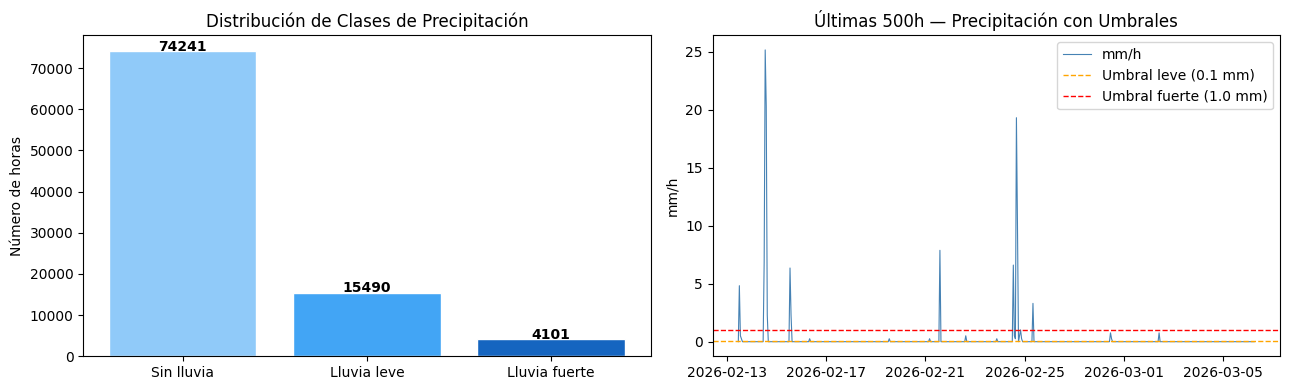

In [31]:
# ============================================================
# UMBRALES DE CLASIFICACIÓN — Ajusta si es necesario
# ============================================================
UMBRAL_LEVE   = 0.1
UMBRAL_FUERTE = 1.0   # mm/h — umbral lluvia fuerte

def clasificar_lluvia(mm):
    if mm < UMBRAL_LEVE:
        return 0   # Sin lluvia
    elif mm <= UMBRAL_FUERTE:
        return 1   # Lluvia leve
    else:
        return 2   # Lluvia fuerte

df_hourly['rain_class'] = df_hourly[RAIN_COL].apply(clasificar_lluvia)

# Distribución de clases
class_counts = df_hourly['rain_class'].value_counts().sort_index()
class_labels = {0: 'Sin lluvia', 1: 'Lluvia leve', 2: 'Lluvia fuerte'}
print('=== Distribución de clases ===')
for cls, cnt in class_counts.items():
    pct = cnt / len(df_hourly) * 100
    print(f'  Clase {cls} ({class_labels[cls]}): {cnt:5d} muestras ({pct:.1f}%)')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['#90CAF9', '#42A5F5', '#1565C0']
axes[0].bar([class_labels[i] for i in range(3)], class_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Distribución de Clases de Precipitación')
axes[0].set_ylabel('Número de horas')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].plot(df_hourly.index[-500:], df_hourly[RAIN_COL][-500:], color='steelblue', linewidth=0.8, label='mm/h')
axes[1].axhline(UMBRAL_LEVE,   color='orange', linestyle='--', linewidth=1, label=f'Umbral leve ({UMBRAL_LEVE} mm)')
axes[1].axhline(UMBRAL_FUERTE, color='red',    linestyle='--', linewidth=1, label=f'Umbral fuerte ({UMBRAL_FUERTE} mm)')
axes[1].set_title('Últimas 500h — Precipitación con Umbrales')
axes[1].set_ylabel('mm/h'); axes[1].legend()

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Preprocesamiento de Features

In [32]:
FEATURES = [
    'SlrkW_Avg',    # Radiación solar
    'SlrMJ_Tot',    # Energía solar acumulada
    'WS_ms_Avg',    # Velocidad viento
    'NR_Wm2_Avg',   # Radiación neta
    'VW',           # Humedad suelo sensor 1
    'VW_2',         # Humedad suelo sensor 2
    'VW_3',         # Humedad suelo sensor 3
    'WindDir',      # Dirección del viento
    'Rain_mm_Tot',  # Precipitación (como feature continua)
]

data = df_hourly[FEATURES].copy()
data = data.interpolate(method='linear', limit=6).dropna()

# Features temporales cíclicas
data['hour_sin']  = np.sin(2 * np.pi * data.index.hour / 24)
data['hour_cos']  = np.cos(2 * np.pi * data.index.hour / 24)
data['month_sin'] = np.sin(2 * np.pi * data.index.month / 12)
data['month_cos'] = np.cos(2 * np.pi * data.index.month / 12)

# Lags de lluvia
data['Rain_lag1'] = data['Rain_mm_Tot'].shift(1)
data['Rain_lag2'] = data['Rain_mm_Tot'].shift(2)
data['Rain_lag3'] = data['Rain_mm_Tot'].shift(3)

# Alinear etiquetas con el DataFrame procesado
labels = df_hourly['rain_class'].reindex(data.index)
data   = data.dropna()
labels = labels.reindex(data.index)

print(f'Shape features : {data.shape}')
print(f'Shape etiquetas: {labels.shape}')
print(f'Features ({len(data.columns)}): {data.columns.tolist()}')

Shape features : (71302, 16)
Shape etiquetas: (71302,)
Features (16): ['SlrkW_Avg', 'SlrMJ_Tot', 'WS_ms_Avg', 'NR_Wm2_Avg', 'VW', 'VW_2', 'VW_3', 'WindDir', 'Rain_mm_Tot', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'Rain_lag1', 'Rain_lag2', 'Rain_lag3']


## 6. Normalización y División de Datos

In [33]:
# ============================================================
# PARÁMETROS GLOBALES
# ============================================================
LOOK_BACK  = 24    # 24 horas previas
N_CLASSES  = 3
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
EPOCHS     = 100
BATCH_SIZE = 32
PATIENCE   = 10

n_total    = len(data)
n_train    = int(n_total * TRAIN_FRAC)
n_val      = int(n_total * VAL_FRAC)
n_features = data.shape[1]

# Normalización (fit solo en train)
scaler     = MinMaxScaler(feature_range=(0, 1))
data_np    = data.values.astype(np.float32)
labels_np  = labels.values.astype(np.int32)

scaler.fit(data_np[:n_train])
data_scaled = scaler.transform(data_np)

print(f'Total    : {n_total}')
print(f'Train    : {n_train}')
print(f'Val      : {n_val}')
print(f'Test     : {n_total - n_train - n_val}')
print(f'Features : {n_features}')

Total    : 71302
Train    : 49911
Val      : 10695
Test     : 10696
Features : 16


## 7. Creación de Secuencias para Clasificación (Horizonte +1h)

In [34]:
def create_sequences_clf(data_scaled, labels, look_back, horizon=1):
    """
    Crea ventanas deslizantes para clasificación.
    
    Returns
    -------
    X : (samples, look_back, n_features)
    y : (samples,)  — clase en t + horizon
    """
    X, y = [], []
    n = len(data_scaled)
    for i in range(n - look_back - horizon + 1):
        X.append(data_scaled[i : i + look_back, :])
        y.append(labels[i + look_back + horizon - 1])
    return np.array(X), np.array(y)


X_all, y_all = create_sequences_clf(data_scaled, labels_np, LOOK_BACK, horizon=1)

# División temporal
X_train = X_all[:n_train];          y_train = y_all[:n_train]
X_val   = X_all[n_train:n_train+n_val]; y_val = y_all[n_train:n_train+n_val]
X_test  = X_all[n_train+n_val:];    y_test  = y_all[n_train+n_val:]

# One-hot encoding para la pérdida categorical_crossentropy
y_train_cat = to_categorical(y_train, N_CLASSES)
y_val_cat   = to_categorical(y_val,   N_CLASSES)
y_test_cat  = to_categorical(y_test,  N_CLASSES)

print(f'Train : {X_train.shape}  |  y: {y_train_cat.shape}')
print(f'Val   : {X_val.shape}    |  y: {y_val_cat.shape}')
print(f'Test  : {X_test.shape}   |  y: {y_test_cat.shape}')

# Distribución de clases en train
unique, counts = np.unique(y_train, return_counts=True)
print('\nClases en train:')
for u, c in zip(unique, counts):
    print(f'  Clase {u} ({class_labels[u]}): {c} ({c/len(y_train)*100:.1f}%)')

Train : (49911, 24, 16)  |  y: (49911, 3)
Val   : (10695, 24, 16)    |  y: (10695, 3)
Test  : (10672, 24, 16)   |  y: (10672, 3)

Clases en train:
  Clase 0 (Sin lluvia): 39053 (78.2%)
  Clase 1 (Lluvia leve): 8583 (17.2%)
  Clase 2 (Lluvia fuerte): 2275 (4.6%)


## 8. Pesos de Clase para Manejo del Desbalance

=== Pesos de clase ===
  Clase 0 (Sin lluvia): peso = 0.4260
  Clase 1 (Lluvia leve): peso = 1.9384
  Clase 2 (Lluvia fuerte): peso = 7.3130


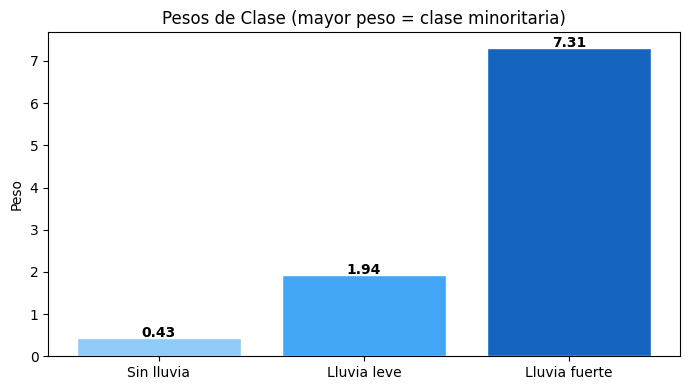

In [35]:
# Calcula pesos inversamente proporcionales a la frecuencia de cada clase
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}

print('=== Pesos de clase ===')
for cls, w in class_weight_dict.items():
    print(f'  Clase {cls} ({class_labels[cls]}): peso = {w:.4f}')

# Visualización de pesos
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([class_labels[i] for i in range(N_CLASSES)], class_weights_arr,
       color=colors, edgecolor='white')
ax.set_title('Pesos de Clase (mayor peso = clase minoritaria)')
ax.set_ylabel('Peso')
for i, v in enumerate(class_weights_arr):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('pesos_clase.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Arquitectura TNN para Clasificación

In [36]:
def build_tnn_classifier(look_back, n_features, n_classes,
                          filters1=64, filters2=128, kernel_size=3,
                          dropout=0.3, lr=1e-3):
    """TNN (Conv1D) para clasificación multiclase."""
    model = Sequential([
        # Bloque 1
        Conv1D(filters=filters1, kernel_size=kernel_size, activation='relu',
               padding='same', input_shape=(look_back, n_features)),
        BatchNormalization(),
        Dropout(dropout),

        # Bloque 2
        Conv1D(filters=filters2, kernel_size=kernel_size, activation='relu',
               padding='same'),
        BatchNormalization(),
        Dropout(dropout),

        # Bloque 3
        Conv1D(filters=filters2, kernel_size=kernel_size, activation='relu',
               padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(dropout),

        # Clasificación
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(dropout),
        Dense(64, activation='relu'),
        Dropout(dropout),
        Dense(n_classes, activation='softmax')   # <-- softmax para clasificación
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',          # <-- pérdida de clasificación
        metrics=['accuracy']
    )
    return model


model = build_tnn_classifier(LOOK_BACK, n_features, N_CLASSES)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 24, 64)         │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 24, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 24, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,587 (1.08 MB)

 Trainable params: 282,947 (1.08 MB)

 Non-trainable params: 640 (2.50 KB)

## 10. Entrenamiento

In [37]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weight_dict,   # <-- manejo del desbalance
    verbose=1
)

Epoch 1/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.5248 - loss: 1.0311 - val_accuracy: 0.5453 - val_loss: 0.9942 - learning_rate: 0.0010
Epoch 2/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6013 - loss: 0.8997 - val_accuracy: 0.5203 - val_loss: 0.9847 - learning_rate: 0.0010
Epoch 3/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6315 - loss: 0.8527 - val_accuracy: 0.7586 - val_loss: 0.6278 - learning_rate: 0.0010
Epoch 4/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6538 - loss: 0.8294 - val_accuracy: 0.5694 - val_loss: 0.8867 - learning_rate: 0.0010
Epoch 5/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6654 - loss: 0.8108 - val_accuracy: 0.5941 - val_loss: 0.8611 - learning_rate: 0.0010
Epoch 6/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6709 - loss: 0.7989 - val_accuracy: 0.8075 - val_loss: 0.5589 - learning_rate: 0.0010
Epoch 7/100
1560/1560 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step -

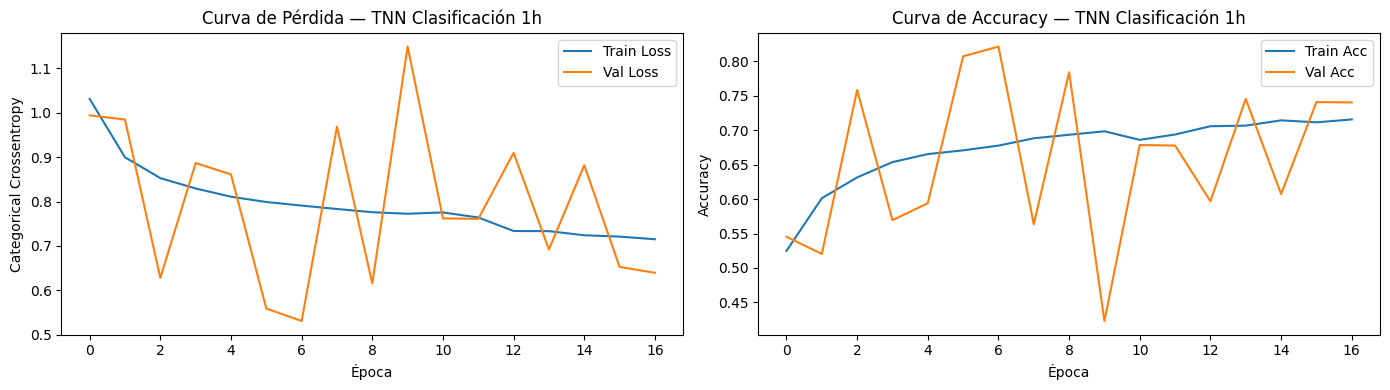

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Curva de Pérdida — TNN Clasificación 1h')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Curva de Accuracy — TNN Clasificación 1h')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('loss_accuracy_clf_1h.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Evaluación en Test

In [39]:
# Predicciones
y_pred_prob = model.predict(X_test)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test

# Métricas globales
acc     = accuracy_score(y_true, y_pred)
f1_mac  = f1_score(y_true, y_pred, average='macro')
f1_wei  = f1_score(y_true, y_pred, average='weighted')

print(f'\n📊 Métricas — TNN Clasificación 1h')
print(f'   Accuracy       : {acc:.4f}')
print(f'   F1 Macro       : {f1_mac:.4f}')
print(f'   F1 Weighted    : {f1_wei:.4f}')
print(f'\n{"="*50}')
print(classification_report(
    y_true, y_pred,
    target_names=[class_labels[i] for i in range(N_CLASSES)]
))

334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

📊 Métricas — TNN Clasificación 1h
   Accuracy       : 0.7879
   F1 Macro       : 0.5592
   F1 Weighted    : 0.7764

               precision    recall  f1-score   support

   Sin lluvia       0.88      0.91      0.90      8254
  Lluvia leve       0.46      0.25      0.32      1713
Lluvia fuerte       0.36      0.61      0.46       705

     accuracy                           0.79     10672
    macro avg       0.57      0.59      0.56     10672
 weighted avg       0.78      0.79      0.78     10672



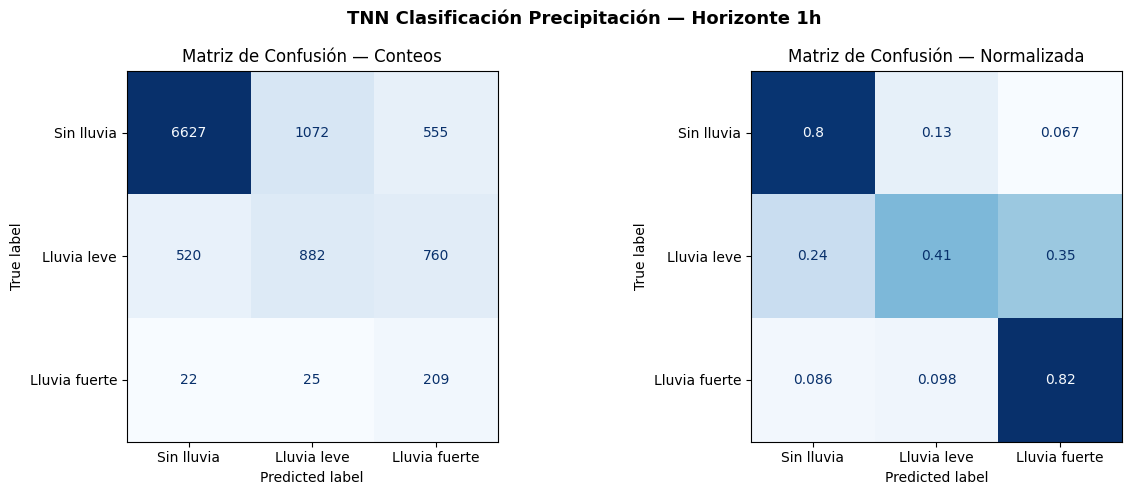

In [26]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm,      display_labels=[class_labels[i] for i in range(N_CLASSES)]).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión — Conteos')

ConfusionMatrixDisplay(cm_norm, display_labels=[class_labels[i] for i in range(N_CLASSES)]).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusión — Normalizada')

plt.suptitle('TNN Clasificación Precipitación — Horizonte 1h', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_1h.png', dpi=120, bbox_inches='tight')
plt.show()

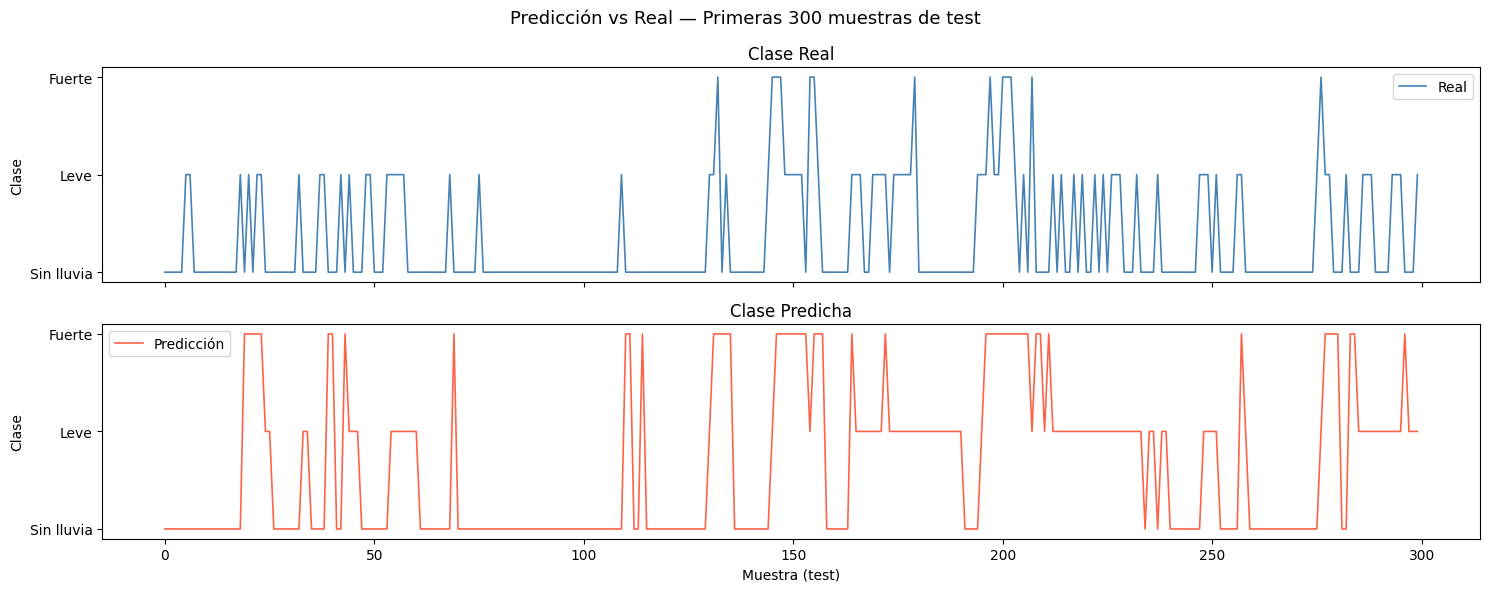

In [27]:
# Comparación temporal: clases reales vs predichas
n_show = min(300, len(y_true))
fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

axes[0].plot(range(n_show), y_true[:n_show], color='steelblue', linewidth=1.2, label='Real')
axes[0].set_title('Clase Real'); axes[0].set_ylabel('Clase'); axes[0].set_yticks([0,1,2])
axes[0].set_yticklabels(['Sin lluvia', 'Leve', 'Fuerte'])
axes[0].legend()

axes[1].plot(range(n_show), y_pred[:n_show], color='tomato', linewidth=1.2, label='Predicción')
axes[1].set_title('Clase Predicha'); axes[1].set_ylabel('Clase'); axes[1].set_yticks([0,1,2])
axes[1].set_yticklabels(['Sin lluvia', 'Leve', 'Fuerte'])
axes[1].set_xlabel('Muestra (test)')
axes[1].legend()

plt.suptitle(f'Predicción vs Real — Primeras {n_show} muestras de test', fontsize=13)
plt.tight_layout()
plt.savefig('pred_vs_real_clf_1h.png', dpi=120, bbox_inches='tight')
plt.show()

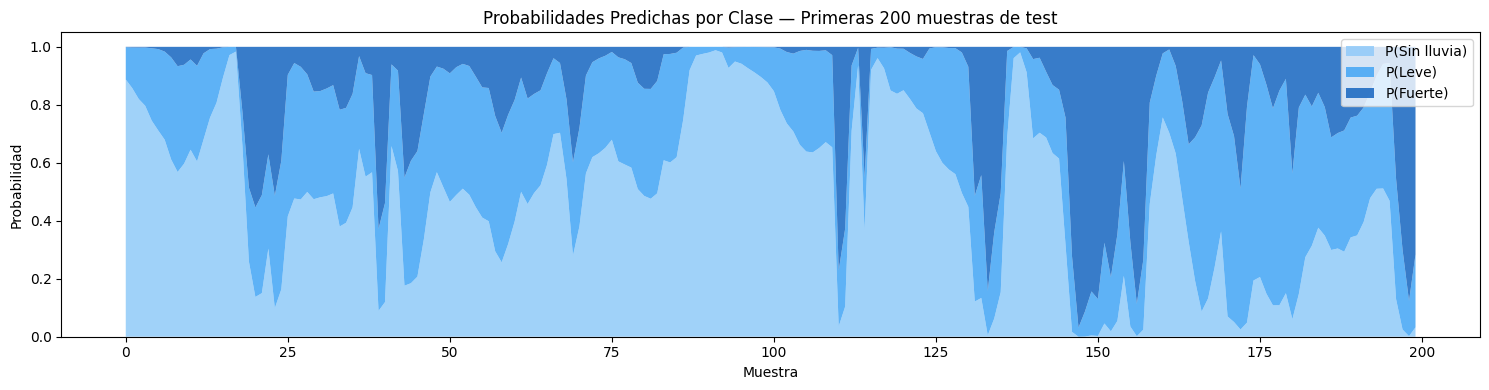

In [28]:
# Probabilidades predichas por clase
n_show = min(200, len(y_pred_prob))
fig, ax = plt.subplots(figsize=(15, 4))

ax.stackplot(
    range(n_show),
    y_pred_prob[:n_show, 0],
    y_pred_prob[:n_show, 1],
    y_pred_prob[:n_show, 2],
    labels=['P(Sin lluvia)', 'P(Leve)', 'P(Fuerte)'],
    colors=['#90CAF9', '#42A5F5', '#1565C0'],
    alpha=0.85
)
ax.set_title('Probabilidades Predichas por Clase — Primeras 200 muestras de test')
ax.set_xlabel('Muestra'); ax.set_ylabel('Probabilidad')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('probabilidades_clf_1h.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Guardado del Modelo

In [29]:
import joblib

model.save('tnn_clf_1h.keras')
joblib.dump(scaler, 'scaler_clf_JUN.pkl')

# Guardar configuración de umbrales
config = {
    'umbral_leve'  : UMBRAL_LEVE,
    'umbral_fuerte': UMBRAL_FUERTE,
    'look_back'    : LOOK_BACK,
    'n_classes'    : N_CLASSES,
    'class_labels' : class_labels,
    'features'     : data.columns.tolist()
}
import json
with open('config_clf_JUN.json', 'w') as f:
    json.dump(config, f, indent=2)

print('✅ Modelo, scaler y configuración guardados.')
print('   tnn_clf_1h.keras')
print('   scaler_clf_JUN.pkl')
print('   config_clf_JUN.json')

✅ Modelo, scaler y configuración guardados.
   tnn_clf_1h.keras
   scaler_clf_JUN.pkl
   config_clf_JUN.json


In [30]:
print(df_hourly[RAIN_COL].describe())
print(f"\nPercentil 90: {df_hourly[RAIN_COL].quantile(0.90):.2f} mm/h")
print(f"Percentil 95: {df_hourly[RAIN_COL].quantile(0.95):.2f} mm/h")
print(f"Percentil 99: {df_hourly[RAIN_COL].quantile(0.99):.2f} mm/h")
print(f"\nHoras con lluvia > 0.1mm : {(df_hourly[RAIN_COL] > 0.1).sum()}")
print(f"Horas con lluvia > 1mm  : {(df_hourly[RAIN_COL] > 1.0).sum()}")
print(f"Horas con lluvia > 2mm  : {(df_hourly[RAIN_COL] > 2.0).sum()}")
print(f"Horas con lluvia > 5mm  : {(df_hourly[RAIN_COL] > 5.0).sum()}")
print(f"Horas con lluvia > 10mm : {(df_hourly[RAIN_COL] > 10.0).sum()}")
print(f"\nTotal horas: {len(df_hourly)}")

count    93832.000000
mean         0.178376
std          0.950017
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         63.760000
Name: Rain_mm_Tot, dtype: float64

Percentil 90: 0.25 mm/h
Percentil 95: 0.76 mm/h
Percentil 99: 2.79 mm/h

Horas con lluvia > 0.1mm : 19591
Horas con lluvia > 1mm  : 4101
Horas con lluvia > 2mm  : 1617
Horas con lluvia > 5mm  : 410
Horas con lluvia > 10mm : 132

Total horas: 93832


---
## 📝 Resumen Metodológico — TNN Clasificación

| Etapa | Detalle |
|---|---|
| **Tarea** | Clasificación multiclase (3 clases) |
| **Clases** | 0: Sin lluvia (0 mm/h) \| 1: Leve (0.1–5 mm/h) \| 2: Fuerte (>5 mm/h) |
| **Resampleo** | 15 min → 1h: media continuas, **suma** lluvia |
| **Features** | SlrkW, SlrMJ, WS_ms, NR_Wm2, VW (1-3), WindDir + Rain + temporales + lags |
| **Look_back** | 24 horas previas |
| **Horizonte** | +1 hora |
| **Salida** | Dense(3, softmax) |
| **Pérdida** | categorical_crossentropy |
| **Desbalance** | class_weight='balanced' |
| **Normalización** | MinMaxScaler [0,1], fit solo en train |
| **División** | 70% train / 15% val / 15% test (orden temporal) |
| **Métricas** | Accuracy, F1 macro, F1 weighted, Matriz de confusión |